Basic LangGraph Agent with Two Simple Nodes

In [1]:
from typing import TypedDict

class USDINRRemit(TypedDict):
    usd_Amount: float
    usd_ReturnTotal: float
    inr_Total: float

def calcUSDTotal(state: USDINRRemit) -> USDINRRemit:
    state['usd_ReturnTotal'] = state['usd_Amount'] * 1.04
    return state

def convertINRTotal(state: USDINRRemit) -> USDINRRemit:
    state['inr_Total'] = state['usd_ReturnTotal'] * 89
    return state



Define LangGraph Edges and Nodes

In [2]:
from langgraph.graph import StateGraph, START, END

builder = StateGraph(USDINRRemit)

builder.add_node("calcUSDTotal_Node", calcUSDTotal)
builder.add_node("convertINRTotal_Node", convertINRTotal)

builder.add_edge(START,"calcUSDTotal_Node")
builder.add_edge("calcUSDTotal_Node","convertINRTotal_Node")
builder.add_edge("convertINRTotal_Node",END)

graph = builder.compile()

c:\Users\Arun.Manglick\AppData\Local\Programs\Python\Python314\Lib\site-packages\langchain_core\_api\deprecation.py:26: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


Display Graph

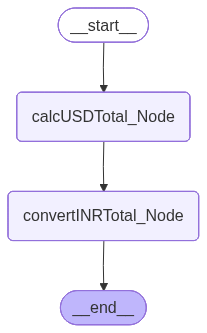

In [3]:
from IPython.display import Image, display
display(graph)

Run Graph

In [4]:
graph.invoke({"usd_Amount": 1000})

{'usd_Amount': 1000, 'usd_ReturnTotal': 1040.0, 'inr_Total': 92560.0}